# Segmentação de Clientes por Perfil de Churn
## PRT Seguros

**Entrega:** segmentação dos clientes em grupos de perfil semelhante, com a taxa média de churn de
cada grupo — para orientar em quais perfis a PRT Seguros deve concentrar esforço de retenção.

**Importante — consistência com o modelo final:** os clusters usados aqui são **exatamente os
mesmos** já calculados dentro do pipeline de modelagem (`modelagem_caue/00_preparacao_dados.ipynb`),
que por sua vez alimentam o modelo vencedor (`modelagem_caue/25_modelo_final_vencedor.ipynb`).
Não recalculamos o K-Means aqui — carregamos os arquivos já processados, então o cluster de cada
cliente neste relatório é o mesmo número que o modelo usa internamente. Isso garante que a
segmentação de negócio e a feature usada pelo modelo preditivo contam a mesma história.

- **Algoritmo:** K-Means, **K = 7** (atualizado em 2026-07-09 — ver seção 3: testamos vários K
  diretamente contra o score real do Kaggle depois de perder a liderança da competição, e K=7 deu
  o melhor resultado, superando o K=6 usado até então)
- **Base:** os 100.000 clientes de `Base_Unificada_Outer.csv` (toda a base com rótulo de churn conhecido)
- **Features usadas para formar os clusters:** 22 variáveis numéricas/binárias mais correlacionadas
  com churn (tempo de relacionamento, apólices, produtos, desconto, índice de relacionamento, NPS,
  tipo de cobertura, renda, patrimônio, engajamento digital, reclamações — a lista completa está em
  `FEATURES_CLUSTER` no notebook `00_preparacao_dados.ipynb`)


## 1. Carregar os clientes já com o cluster atribuído pelo pipeline de modelagem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PRT_NAVY, PRT_GREEN, PRT_GRAY = "#19284F", "#39694B", "#737C8A"

train = pd.read_csv("../modelagem_caue/dados_processados/train_model_ready.csv")
val = pd.read_csv("../modelagem_caue/dados_processados/val_model_ready.csv")
df = pd.concat([train, val], ignore_index=True)

df["cluster"] = df["cluster"].astype(int)
print(f"Total de clientes: {len(df):,}")
print(f"Clusters: {sorted(df['cluster'].unique())}")


Total de clientes: 100,000
Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## 2. Preparar as features usadas na clusterização

Mesmas 22 variáveis usadas pelo K-Means do pipeline de modelagem (`FEATURES_CLUSTER` em
`00_preparacao_dados.ipynb`) — precisamos delas aqui tanto para a visualização em PCA quanto para
os gráficos de cotovelo/silhueta abaixo.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

FEATURES_CLUSTER = [
    "tempo_cliente_dias", "num_apolices_ativas", "num_produtos_contratados",
    "desconto_aplicado_pct", "indice_relacionamento", "satisfacao_nps",
    "tipo_cobertura_basica", "estado_civil", "tipo_cobertura_premium",
    "tem_filhos", "renda_anual", "qtd_dependentes", "valor_imovel",
    "valor_cobertura_total", "idade", "score_engajamento_digital",
    "pagamento_em_dia", "num_reclamacoes_12m", "num_acessos_app_mes",
    "possui_imovel", "tipo_cobertura_padrao",
]

X_imputado = SimpleImputer(strategy="median").fit_transform(df[FEATURES_CLUSTER])
X_scaled = StandardScaler().fit_transform(X_imputado)
print(f"Matriz usada na clusterização: {X_scaled.shape}")


Matriz usada na clusterização: (100000, 21)


## 3. Por que K = 7? Cotovelo, Silhueta — e o teste real que decidiu

**Histórico:** originalmente usávamos K=6, escolhido por bom senso de negócio (nem cotovelo nem
silhueta apontavam um K "ótimo" claro — ver leitura dos gráficos abaixo). Depois que uma equipe
concorrente superou a nossa posição no Kaggle, testamos **sistematicamente K=3,4,5,6,7,8,10,12**
treinando o modelo final (Random Forest + Extra Trees) para cada um e comparando o score real no
Kaggle — não só a métrica interna de cluster. **K=7 venceu** (recuperou o 1º lugar), mesmo com
inércia/silhueta praticamente idênticas a K=6. Isso é uma lição importante: a métrica que decide
o K de verdade aqui é o **impacto no problema de negócio final (prever churn)**, não a métrica de
clusterização isolada — os dois métodos abaixo ficam como referência estatística, não como critério
único de decisão.

**Método do Cotovelo:** roda o K-Means para vários valores de K e mede a **inércia** (soma das
distâncias ao quadrado de cada cliente até o centro do seu cluster — quanto menor, mais compacto o
cluster). A inércia **sempre cai** conforme K aumenta, então o que se procura é o ponto onde a curva
para de cair de forma acentuada ("cotovelo").

**Método da Silhueta:** mede, para cada cliente, o quão mais parecido ele é do seu próprio cluster
do que do cluster vizinho mais próximo. Varia de **-1 a 1** — quanto maior, mais bem separados e
coesos estão os grupos.

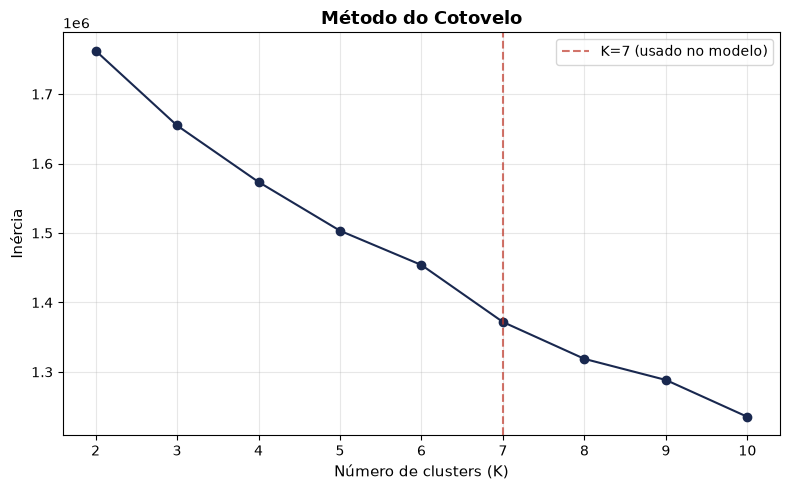

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
K_RANGE = range(2, 11)

inercias = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_RANGE), inercias, marker="o", color=PRT_NAVY)
ax.axvline(x=7, color="#c0392b", linestyle="--", alpha=0.7, label="K=7 (usado no modelo)")
ax.set_xlabel("Número de clusters (K)", fontsize=11)
ax.set_ylabel("Inércia", fontsize=11)
ax.set_title("Método do Cotovelo", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


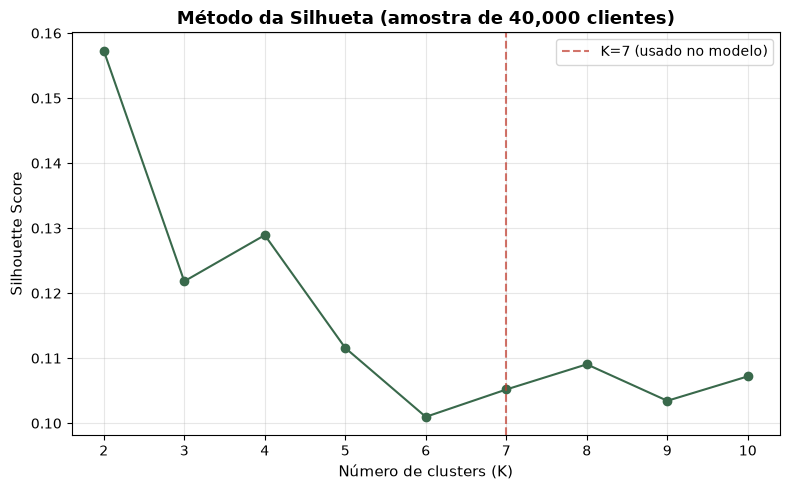

{2: 0.1573, 3: 0.1218, 4: 0.1289, 5: 0.1116, 6: 0.101, 7: 0.1052, 8: 0.1091, 9: 0.1034, 10: 0.1072}


In [4]:
# Amostra para acelerar o cálculo (silhouette_score é O(n²) — inviável em 100 mil linhas)
SILHOUETTE_SAMPLE = 40_000
rng = np.random.default_rng(RANDOM_STATE)

silhuetas = {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    idx = rng.choice(len(X_scaled), size=SILHOUETTE_SAMPLE, replace=False)
    silhuetas[k] = silhouette_score(X_scaled[idx], labels[idx])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(silhuetas.keys()), list(silhuetas.values()), marker="o", color=PRT_GREEN)
ax.axvline(x=7, color="#c0392b", linestyle="--", alpha=0.7, label="K=7 (usado no modelo)")
ax.set_xlabel("Número de clusters (K)", fontsize=11)
ax.set_ylabel("Silhouette Score", fontsize=11)
ax.set_title(f"Método da Silhueta (amostra de {SILHOUETTE_SAMPLE:,} clientes)", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print({k: round(v, 4) for k, v in silhuetas.items()})


**Leitura dos dois gráficos:** assim como antes, nenhum dos dois aponta K=7 como o pico
estatístico isolado (o comportamento geral — cotovelo suave, silhueta mais alta em K pequeno — é o
mesmo de quando K=6 estava em uso). Isso confirma o ponto da seção 3: escolhemos K=7 pelo resultado
real no problema de negócio (score de churn no Kaggle), não porque a silhueta o recomendasse. Vale
manter esse tipo de validação empírica no radar sempre que alguém for reconsiderar o K no futuro —
não confiar só no gráfico de silhueta.

## 4. Reconstruir categorias legíveis

As colunas de categoria vêm em one-hot (`tipo_cobertura_basica`, `tipo_cobertura_padrao`, ...) —
juntamos de volta numa única coluna por categoria, só para deixar o perfil fácil de ler.

In [5]:
GRUPOS_CATEGORICOS = {
    "tipo_cobertura": ["tipo_cobertura_NaN", "tipo_cobertura_basica", "tipo_cobertura_padrao", "tipo_cobertura_premium"],
    "segmento": ["segmento_Bronze", "segmento_Diamante", "segmento_NaN", "segmento_Ouro", "segmento_Prata"],
    "escolaridade": ["escolaridade_Fundamental", "escolaridade_Medio", "escolaridade_NaN", "escolaridade_Pos", "escolaridade_Superior"],
    "canal_aquisicao": ["canal_aquisicao_Agente", "canal_aquisicao_Digital", "canal_aquisicao_Indicacao", "canal_aquisicao_NaN", "canal_aquisicao_Telefone"],
    "metodo_pagamento": ["metodo_pagamento_NaN", "metodo_pagamento_boleto", "metodo_pagamento_credito", "metodo_pagamento_debito", "metodo_pagamento_pix"],
    "veiculo": ["veiculo_Carro", "veiculo_Moto", "veiculo_NaN", "veiculo_Pickup", "veiculo_SUV", "veiculo_Van"],
    "regiao": ["regiao_Centro-Oeste", "regiao_NaN", "regiao_Nordeste", "regiao_Sudeste", "regiao_Sul"],
}

for grupo, cols in GRUPOS_CATEGORICOS.items():
    df[grupo] = df[cols].idxmax(axis=1).str.replace(grupo + "_", "", regex=False)


## 5. Perfil de cada cluster — números que importam para o negócio

Média das principais variáveis + tamanho do grupo + **taxa média de churn** (a probabilidade
histórica de um cliente daquele grupo cancelar a apólice).

In [6]:
NUMERICAS_PERFIL = [
    "tempo_cliente_dias", "num_apolices_ativas", "num_produtos_contratados",
    "indice_relacionamento", "satisfacao_nps", "renda_anual", "valor_imovel",
    "idade", "score_engajamento_digital", "num_reclamacoes_12m", "num_acessos_app_mes",
    "pagamento_em_dia", "qtd_dependentes",
]

perfil = df.groupby("cluster")[NUMERICAS_PERFIL].mean().round(2)
perfil["n_clientes"] = df.groupby("cluster").size()
perfil["pct_da_base"] = (perfil["n_clientes"] / len(df) * 100).round(1)
perfil["taxa_media_churn_pct"] = (df.groupby("cluster")["churned"].mean() * 100).round(2)
perfil["cobertura_predominante"] = df.groupby("cluster")["tipo_cobertura"].agg(lambda x: x.mode().iat[0])

perfil = perfil.sort_values("taxa_media_churn_pct", ascending=False)
perfil


,tempo_cliente_dias,num_apolices_ativas,num_produtos_contratados,indice_relacionamento,satisfacao_nps,renda_anual,valor_imovel,idade,score_engajamento_digital,num_reclamacoes_12m,num_acessos_app_mes,pagamento_em_dia,qtd_dependentes,n_clientes,pct_da_base,taxa_media_churn_pct,cobertura_predominante
cluster,,,,,,,,,,,,,,,,,
0,1438.96,3.52,1.18,52.45,5.89,66267.33,259255.13,40.54,54.75,0.92,10.93,1.00,0.07,28680,28.7,22.08,basica
6,1580.59,3.21,1.30,50.56,5.84,68874.15,300555.39,42.17,54.71,0.93,10.69,0.92,0.92,677,0.7,21.57,basica
4,2095.84,2.64,1.98,44.68,4.29,76738.52,287876.98,42.93,52.14,1.06,10.38,0.00,1.19,5609,5.6,18.26,basica
2,1736.32,2.88,1.45,49.36,5.66,68978.40,270195.05,41.91,54.70,0.98,10.96,1.00,2.31,16073,16.1,18.04,basica
1,2773.04,1.79,2.61,56.93,6.74,87629.70,321242.52,45.22,48.20,0.80,9.63,1.00,2.29,19227,19.2,4.42,padrao
5,3442.69,1.27,3.72,59.11,6.90,95158.81,345718.19,47.28,46.81,0.80,9.34,1.00,0.05,13321,13.3,2.90,premium
3,3320.60,1.32,3.75,57.76,6.84,91870.29,336322.98,46.42,47.98,0.82,9.61,1.00,2.35,16413,16.4,2.78,premium


## 6. Gráfico — taxa de churn por cluster (ordenado do maior para o menor risco)

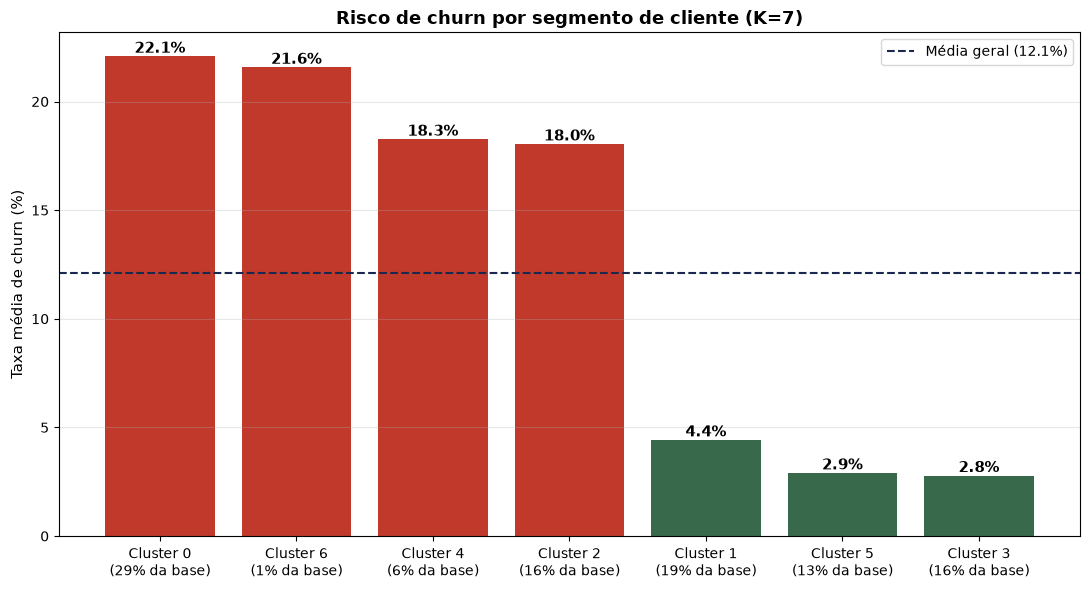

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
cores = [PRT_GREEN if v < perfil["taxa_media_churn_pct"].mean() else "#c0392b" for v in perfil["taxa_media_churn_pct"]]
barras = ax.bar(
    [f"Cluster {c}\n({perfil.loc[c, 'pct_da_base']:.0f}% da base)" for c in perfil.index],
    perfil["taxa_media_churn_pct"], color=cores,
)
ax.axhline(y=df["churned"].mean() * 100, color=PRT_NAVY, linestyle="--",
           label=f"Média geral ({df['churned'].mean()*100:.1f}%)")
for barra in barras:
    altura = barra.get_height()
    ax.annotate(f"{altura:.1f}%", (barra.get_x() + barra.get_width() / 2, altura),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Taxa média de churn (%)", fontsize=11)
ax.set_title("Risco de churn por segmento de cliente (K=7)", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 7. Visualização 2D dos clusters (PCA)

Só para fins de visualização — reduz as 22 variáveis usadas na clusterização (já preparadas na
seção 2) a 2 eixos que preservam o máximo de variância possível.

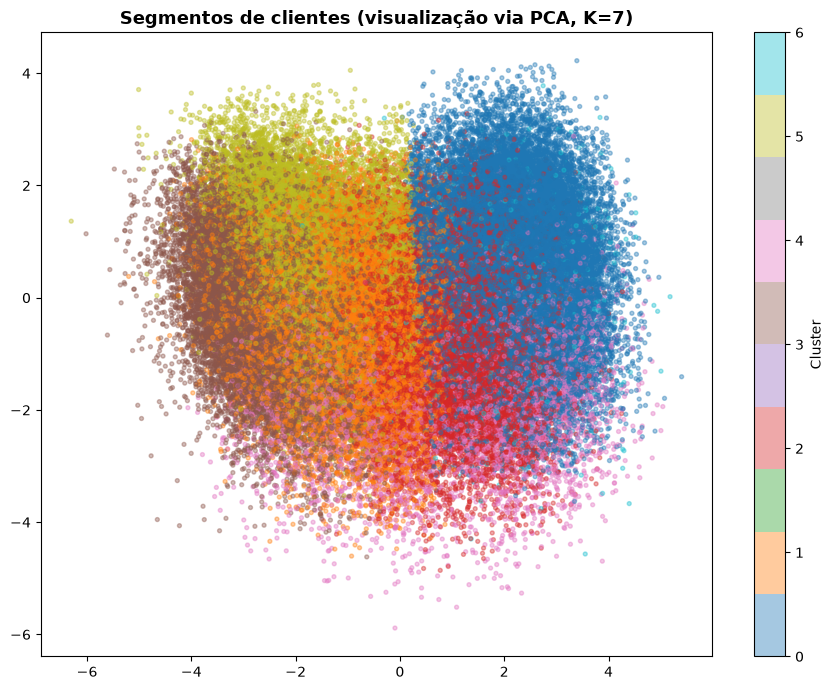

In [8]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df["cluster"], cmap="tab10", alpha=0.4, s=8)
ax.set_title("Segmentos de clientes (visualização via PCA, K=7)", fontsize=13, fontweight="bold")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


## 8. Perfil descritivo de cada cluster — para levar ao cliente

Interpretação em linguagem de negócio, baseada nos números da seção 5 (ordenado do maior para o
menor risco de churn). Com K=7, o antigo "cluster de risco" (K=6) se dividiu em mais subgrupos, e
o antigo "cluster premium" se dividiu em dois perfis diferentes por composição familiar.

| Cluster | % da base | Taxa de churn | Perfil |
|---|---|---|---|
| **0** | 28,7% (maior grupo) | **22,08%** ⚠️ | Clientes **mais novos** (~3,9 anos), **muitas apólices concentradas em poucos produtos** (2,98 apólices/produto), cobertura básica, renda mais baixa (R$ 66,3k), maior desconto aplicado (14%). Maior grupo E maior risco — prioridade #1. |
| **6** | 0,7% (menor grupo) | 21,57% ⚠️ | Perfil muito parecido ao cluster 0 (básica, novo, desconto alto) — mas **nenhum cliente possui imóvel** (0%, vs. 100% no cluster 0), o que os diferencia. Grupo pequeno; monitorar se não é redundante com o cluster 0. |
| **4** | 5,6% | 18,26% ⚠️ | **Menor satisfação (NPS 4,3) e menor índice de relacionamento (44,7)** de todos — e **100% paga em atraso** (`pagamento_em_dia = 0`). Não é sobre ser novo/barato, é insatisfação/atrito já instalado. |
| **2** | 16,1% | 18,04% ⚠️ | Perfil de transição entre o cluster 0 e os clusters saudáveis — cobertura ainda majoritariamente básica (67,7%), mas tempo de casa maior (~4,75 anos). |
| **1** | 19,2% | 4,42% ✅ | Cobertura **padrão** (84,7%), bom tempo de casa (~7,6 anos), renda alta (R$ 87,6k), poucas apólices mas mais produtos (2,61) — baixo risco. |
| **5** | 13,3% | 2,90% ✅ | Mistura premium/padrão (52,8%/28%), maior renda de todos (R$ 95,2k) e melhor relacionamento/NPS — mas **quase sem filhos/dependentes** (0,05 dependentes, 1% com filhos). Perfil "premium sem família". |
| **3** | 16,4% | 2,78% ✅ | **91,5% cobertura premium**, renda alta (R$ 91,9k) — mas ao contrário do cluster 5, **com família** (2,35 dependentes, 100% com filhos). Perfil "premium familiar". |

**Insight central para a estratégia de retenção:** clusters **0, 6, 4 e 2** somam **51,1% da base**
e concentram todo o risco acima da média — mas por **motivos diferentes**: 0/6/2 são clientes
"rasos" (poucos produtos, cobertura básica, novos), enquanto o cluster 4 é sobre **atrito já
instalado** (insatisfação + inadimplência), não maturidade da relação — pede ação de recuperação de
relacionamento, não de cross-sell. Os clusters saudáveis (1, 3, 5 — 48,9% da base) se dividem por
**perfil familiar dentro do segmento premium** (3 = famílias, 5 = sem filhos), o que pode orientar
que tipo de produto complementar oferecer a cada um (ex.: seguro de vida/educação para o cluster 3,
patrimonial para o cluster 5).

> Assim como antes, escolaridade, canal de aquisição, método de pagamento, veículo e região **não
> diferenciam os clusters** — não fizeram parte das variáveis de clusterização e não devem ser
> usadas como critério de segmentação para retenção.
